*Project title-Plant Disease Detection Using CNN and Transfer Learning*
---------------------------------------------

Problem
------

Plants can suffer from various diseases, and identifying the disease manually from leaf symptoms can be difficult and time-consuming.

We want to develop a computer vision model that can examine an image of a plant leaf and classify it into the appropriate disease/healthy category.

Importing the Libraries

In [1]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_path = r"D:\FROM E\imarticus learning courses\Capstone Project 2\Plant Disease Capstone\datasets\PlantVillage\train"

In [3]:
print(os.path.exists(train_path))

True


In [4]:
# Getting the names of all folders/files inside the training directory
classes = os.listdir(train_path)

# Print the total number of items found
print("Number of classes:", len(classes))

# Print the name of every class
print("\nClasses:")
for cls in classes:
    print(cls)

Number of classes: 38

Classes:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___healthy
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_

In [5]:
# Create an empty dictionary to store the number of images in each class
class_counts = {}

# Go through each plant/disease class folder
for cls in classes:
    
    # Create the complete path to the current class folder
    class_path = os.path.join(train_path, cls)
    
    # Get all files/images inside the class folder
    images = os.listdir(class_path)
    
    # Store the number of images for this class
    class_counts[cls] = len(images)

# Display the image count for every class
for cls, count in class_counts.items():
    print(cls, ":", count)

Apple___Apple_scab : 504
Apple___Black_rot : 496
Apple___Cedar_apple_rust : 220
Apple___healthy : 1316
Blueberry___healthy : 1202
Cherry_(including_sour)___healthy : 684
Cherry_(including_sour)___Powdery_mildew : 842
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 410
Corn_(maize)___Common_rust_ : 953
Corn_(maize)___healthy : 929
Corn_(maize)___Northern_Leaf_Blight : 788
Grape___Black_rot : 944
Grape___Esca_(Black_Measles) : 1107
Grape___healthy : 339
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 861
Orange___Haunglongbing_(Citrus_greening) : 4405
Peach___Bacterial_spot : 1838
Peach___healthy : 288
Pepper,_bell___Bacterial_spot : 797
Pepper,_bell___healthy : 1183
Potato___Early_blight : 800
Potato___healthy : 121
Potato___Late_blight : 800
Raspberry___healthy : 297
Soybean___healthy : 4072
Squash___Powdery_mildew : 1468
Strawberry___healthy : 364
Strawberry___Leaf_scorch : 887
Tomato___Bacterial_spot : 1702
Tomato___Early_blight : 800
Tomato___healthy : 1273
Tomato___Late_blight : 

In [6]:
# Add the number of images from all classes.
# .values() gives us only the image counts from the dictionary.
total_train_images = sum(class_counts.values())

# Display the total number of training images.
print("Total number of training images:", total_train_images)

Total number of training images: 43444


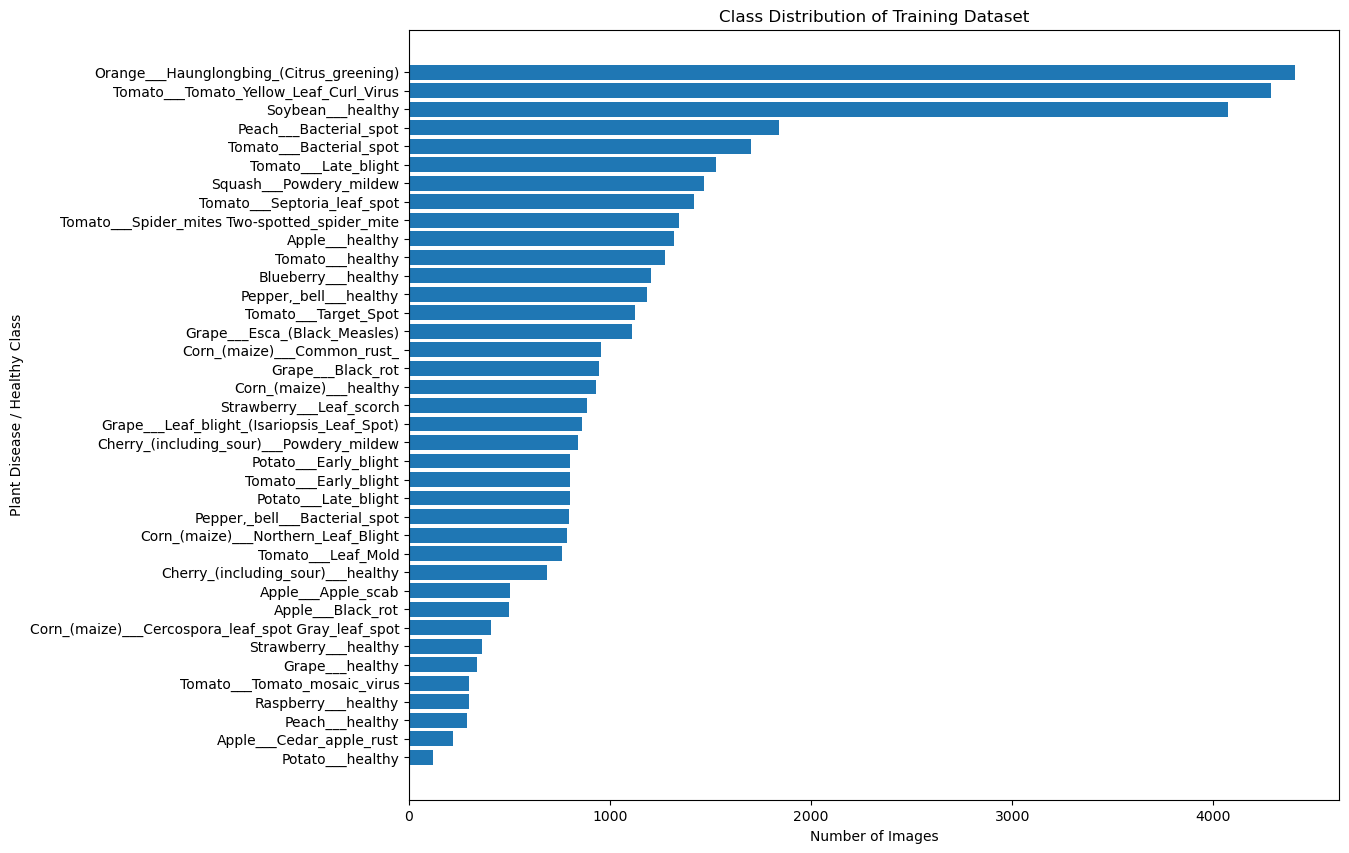

In [7]:
# Convert the class-count dictionary into a Pandas DataFrame.
# This will make the data easier to work with and visualize.
class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number_of_Images"]
)

# Sort the classes by the number of images.
# This makes the graph easier to understand.
class_counts_df = class_counts_df.sort_values(
    by="Number_of_Images"
)

# Create a horizontal bar chart.
plt.figure(figsize=(12, 10))

plt.barh(
    class_counts_df["Class"],
    class_counts_df["Number_of_Images"]
)

# Add labels and title.
plt.xlabel("Number of Images")
plt.ylabel("Plant Disease / Healthy Class")
plt.title("Class Distribution of Training Dataset")

# Display the graph.
plt.show()

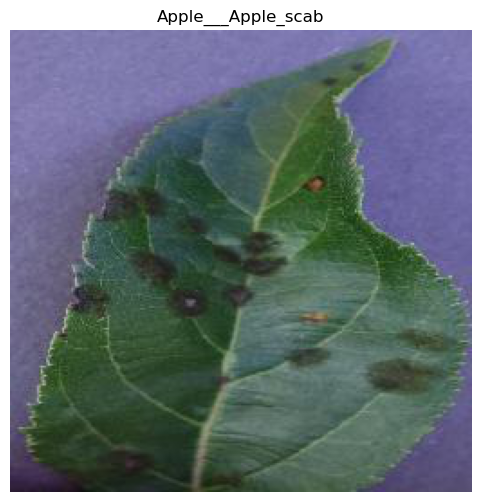

Image size: (256, 256)


In [8]:
# Import the image loading utility from TensorFlow/Keras.
from tensorflow.keras.utils import load_img

# Select the first class from our list of classes.
sample_class = classes[0]

# Create the complete path to that class folder.
sample_class_path = os.path.join(train_path, sample_class)

# Get the list of images inside this class folder.
sample_images = os.listdir(sample_class_path)

# Select the first image.
sample_image = sample_images[0]

# Create the complete path to the selected image.
sample_image_path = os.path.join(sample_class_path, sample_image)

# Load the image.
img = load_img(sample_image_path)

# Display the image.
plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")

plt.show()

# Display the image dimensions.
print("Image size:", img.size)

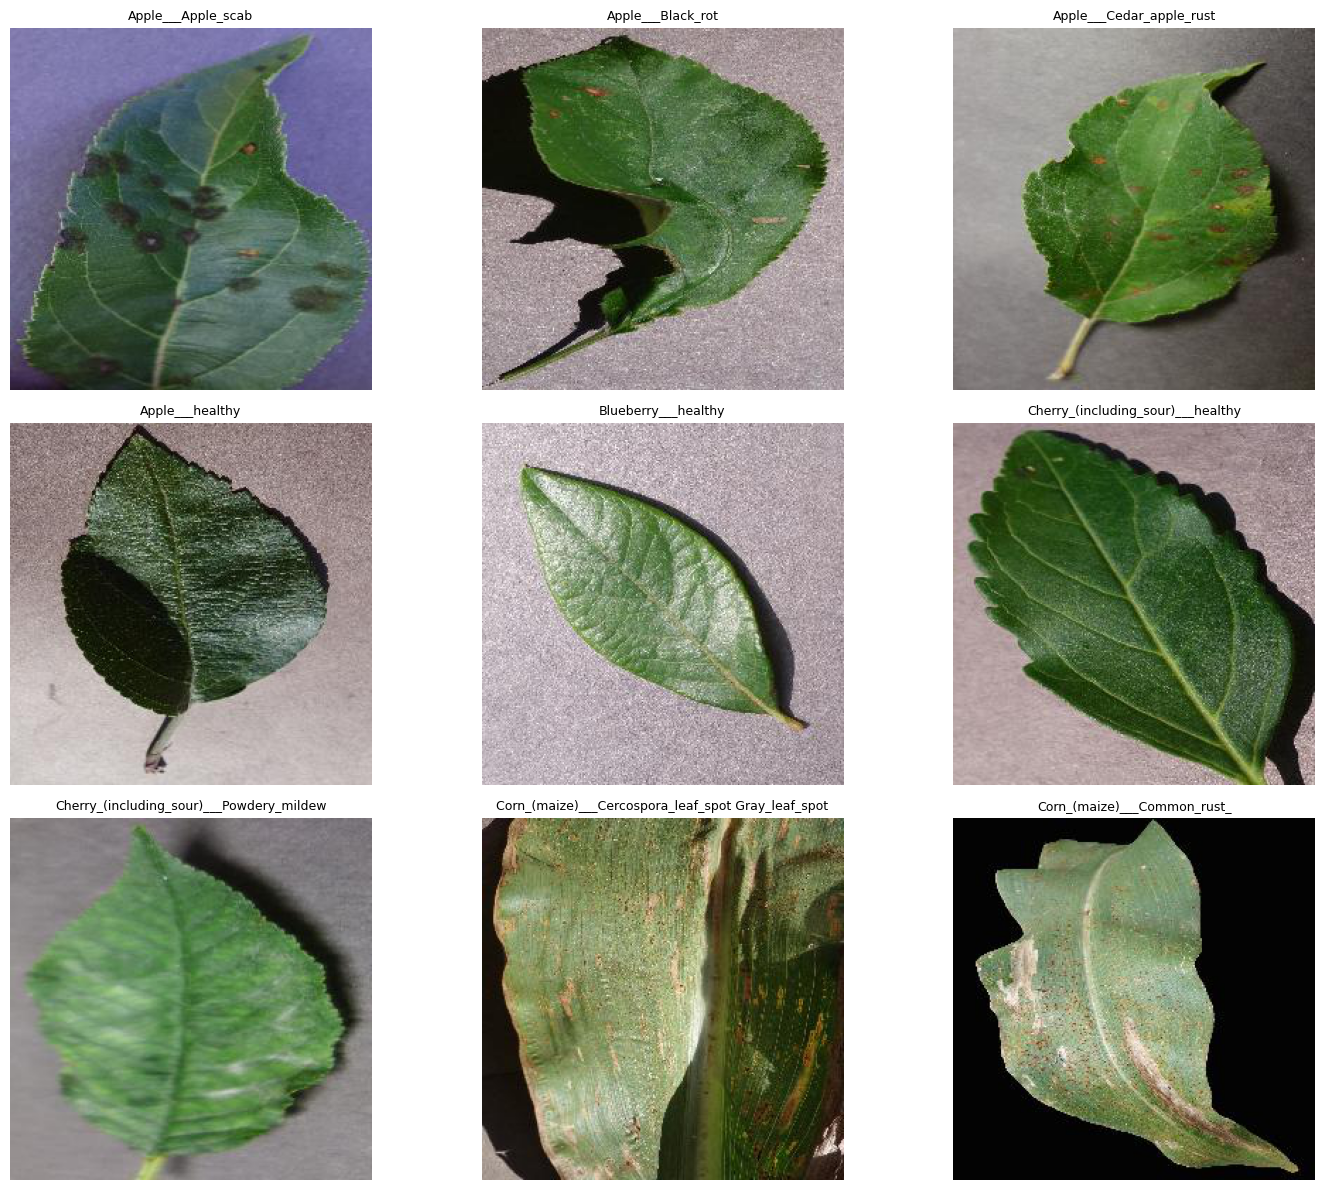

In [9]:
# Create a figure to display multiple images.
plt.figure(figsize=(15, 12))

# Display images from the first 9 classes.
for i, cls in enumerate(classes[:9]):

    # Create the path to the current class folder.
    class_path = os.path.join(train_path, cls)

    # Get all image files from the class folder.
    images = os.listdir(class_path)

    # Select the first image from the current class.
    image_path = os.path.join(class_path, images[0])

    # Load the image.
    img = load_img(image_path)

    # Create a subplot in a 3 × 3 grid.
    plt.subplot(3, 3, i + 1)

    # Display the image.
    plt.imshow(img)

    # Display the class name as the title.
    plt.title(cls, fontsize=9)

    # Hide the axis numbers.
    plt.axis("off")

# Adjust the spacing between the images.
plt.tight_layout()

# Display the complete grid.
plt.show()

In [10]:
# Define the image height that will be given to the neural network.
IMG_HEIGHT = 224

# Define the image width that will be given to the neural network.
IMG_WIDTH = 224

# Number of images processed by the model at one time.
BATCH_SIZE = 32

# Display the configuration.
print("Image height:", IMG_HEIGHT)
print("Image width:", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)

Image height: 224
Image width: 224
Batch size: 32


In [11]:
# Import TensorFlow.
import tensorflow as tf

# Load the training images from the directory structure.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    
    # Location of the training images.
    train_path,
    
    # Resize every image to 224 × 224 pixels.
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    
    # Process 32 images at a time.
    batch_size=BATCH_SIZE,
    
    # Automatically assign labels based on the folder names.
    label_mode="int",
    
    # Keep the class order fixed and consistent.
    shuffle=True,
    
    # Set a fixed seed so that the shuffle is reproducible.
    seed=42
)

# Display the detected class names.
print("\nClass names:")
print(train_dataset.class_names)

Found 43444 files belonging to 38 classes.

Class names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___S

In [12]:
# Define the path to the validation dataset.
val_path = r"D:\FROM E\imarticus learning courses\Capstone Project 2\Plant Disease Capstone\datasets\PlantVillage\val"

# Check whether the validation folder exists.
print("Validation path exists:", os.path.exists(val_path))

Validation path exists: True


In [13]:
# Load the validation images from the validation directory.
val_dataset = tf.keras.utils.image_dataset_from_directory(
    
    # Location of the validation images.
    val_path,
    
    # Resize every image to 224 × 224 pixels.
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    
    # Process 32 images at a time.
    batch_size=BATCH_SIZE,
    
    # Use integer labels for the 38 classes.
    label_mode="int",
    
    # Keep the validation data order fixed.
    shuffle=False
)

# Display the class names detected in the validation dataset.
print("\nValidation class names:")
print(val_dataset.class_names)

Found 10861 files belonging to 38 classes.

Validation class names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 

In [14]:
# Create a normalization layer.
# This scales pixel values from the range 0–255 to the range 0–1.
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply the normalization layer to the training dataset.
normalized_train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

# Apply the same normalization layer to the validation dataset.
normalized_val_dataset = val_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

# Display a confirmation message.
print("Normalization completed.")

Normalization completed.


In [15]:
# Take one batch of images and labels from the normalized training dataset.
for images, labels in normalized_train_dataset.take(1):

    # Display the minimum pixel value in the batch.
    print("Minimum pixel value:", tf.reduce_min(images).numpy())

    # Display the maximum pixel value in the batch.
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [16]:
# Create a data augmentation pipeline.
# These transformations will be applied to training images
# while the model is being trained.

data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally.
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate images slightly.
    tf.keras.layers.RandomRotation(0.1),

    # Randomly zoom into or out of the image.
    tf.keras.layers.RandomZoom(0.1),

], name="data_augmentation")




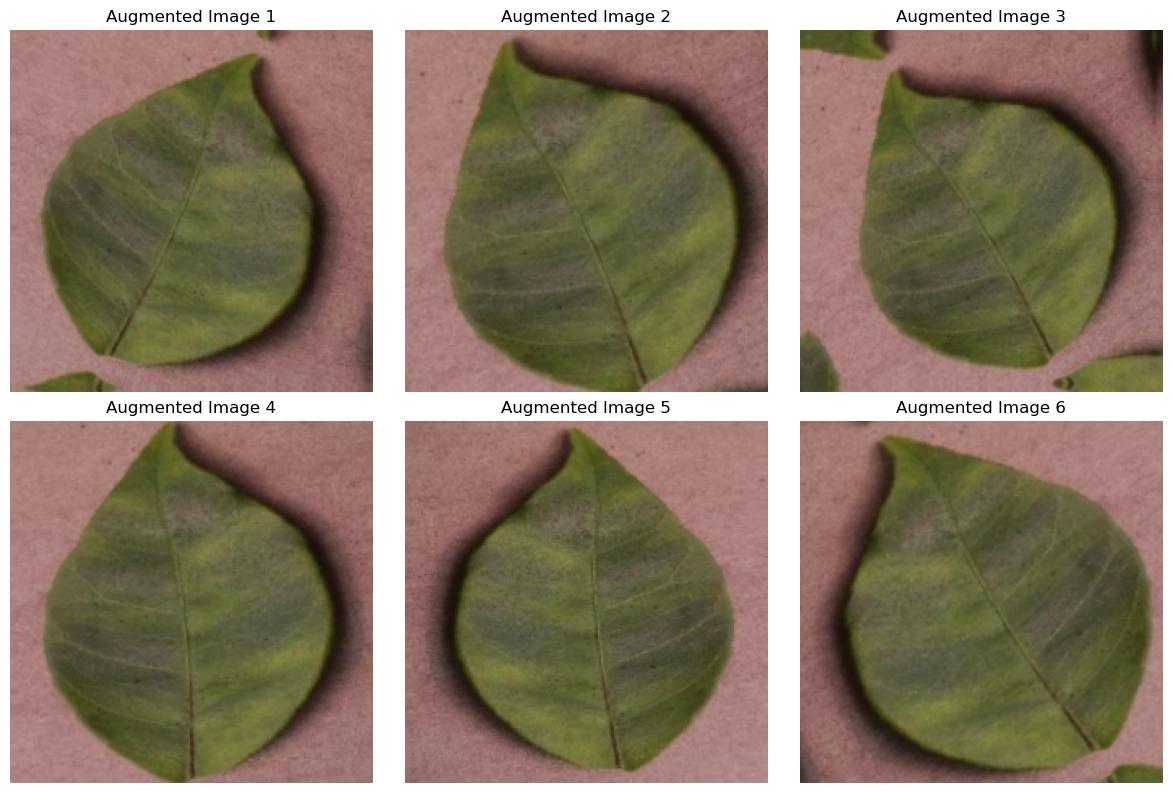

In [17]:
# Take one batch of images from the normalized training dataset.
for images, labels in normalized_train_dataset.take(1):

    # Select the first image from the batch.
    sample_image = images[0]

    # Stop after getting the first batch.
    break


# Create a figure to display the augmented images.
plt.figure(figsize=(12, 8))


# Generate and display 6 augmented versions.
for i in range(6):

    # Apply the augmentation pipeline to the sample image.
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    # Create a subplot in a 2 × 3 grid.
    plt.subplot(2, 3, i + 1)

    # Display the augmented image.
    plt.imshow(augmented_image[0])

    # Remove axis numbers.
    plt.axis("off")

    # Add a title.
    plt.title(f"Augmented Image {i + 1}")


# Adjust the spacing between images.
plt.tight_layout()

# Display the images.
plt.show()

In [18]:
# Build a Sequential CNN model.
# Sequential means the layers are arranged one after another.

cnn_model = tf.keras.Sequential([

    # Input layer.
    # Our images are 224 × 224 pixels with 3 RGB color channels.
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    # First convolutional layer.
    # 32 filters are used to learn basic visual features such as edges and textures.
    # ReLU introduces non-linearity into the network.
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Reduce the spatial dimensions of the feature maps.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolutional layer.
    # 64 filters allow the model to learn more complex features.
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce the feature-map dimensions again.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Third convolutional layer.
    # 128 filters allow the network to learn even more complex patterns.
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Reduce the spatial dimensions again.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert the 2D feature maps into a 1D vector.
    tf.keras.layers.Flatten(),

    # Fully connected layer for classification.
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Randomly deactivate some neurons during training.
    # This helps reduce overfitting.
    tf.keras.layers.Dropout(0.5),

    # Final output layer.
    # We have 38 classes, so we need 38 output neurons.
    tf.keras.layers.Dense(
        38,
        activation="softmax"
    )
])

In [19]:
# Display the architecture and number of parameters
# in our baseline CNN.
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Compile the baseline CNN.
# This defines how the model will calculate errors,
# update its weights, and measure performance.

cnn_model.compile(

    # Sparse categorical crossentropy is suitable because
    # our labels are integers (0, 1, 2, ..., 37).
    loss="sparse_categorical_crossentropy",

    # Adam optimizer updates the model's weights during training.
    optimizer="adam",

    # Accuracy tells us the percentage of correctly classified images.
    metrics=["accuracy"]
)

# Display a confirmation message.
print("CNN model compiled successfully.")

CNN model compiled successfully.


In [22]:
# Build the final baseline CNN with data augmentation included.
cnn_model = tf.keras.Sequential([

    # Input layer.
    # Each image is 224 × 224 pixels with 3 RGB channels.
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    # Apply random transformations to training images.
    # This helps the model generalize better and reduce overfitting.
    data_augmentation,

    # First convolutional layer.
    # Learns basic features such as edges and textures.
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Reduce spatial dimensions.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolutional layer.
    # Learns more complex visual features.
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce spatial dimensions again.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Third convolutional layer.
    # Learns deeper and more complex patterns.
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Reduce spatial dimensions again.
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert the feature maps into a one-dimensional vector.
    tf.keras.layers.Flatten(),

    # Fully connected layer for classification.
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Randomly deactivate 50% of neurons during training.
    # This helps reduce overfitting.
    tf.keras.layers.Dropout(0.5),

    # Final output layer.
    # There are 38 plant disease/healthy classes.
    tf.keras.layers.Dense(
        38,
        activation="softmax"
    )
])


# Compile the CNN.
cnn_model.compile(

    # Suitable for integer-encoded multiclass labels.
    loss="sparse_categorical_crossentropy",

    # Optimizer used to update the model weights.
    optimizer="adam",

    # Track classification accuracy.
    metrics=["accuracy"]
)


# Display the model architecture.
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Create an Early Stopping callback.
# Training will stop if the validation loss does not improve
# for several consecutive epochs.

early_stopping = tf.keras.callbacks.EarlyStopping(

    # Monitor the validation loss during training.
    monitor="val_loss",

    # Stop training if validation loss does not improve
    # for 3 consecutive epochs.
    patience=3,

    # Restore the model weights from the epoch
    # that achieved the best validation loss.
    restore_best_weights=True
)

print("Early stopping callback created.")

Early stopping callback created.


In [25]:
# Save the model whenever validation loss improves.
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(

    # File where the best model will be saved.
    "best_baseline_cnn.keras",

    # Monitor validation loss.
    monitor="val_loss",

    # Save only when validation loss improves.
    save_best_only=True,

    # Tell Keras that lower validation loss is better.
    mode="min"
)

print("Model checkpoint callback created.")

Model checkpoint callback created.


In [26]:
# Store both callbacks in a list.
callbacks = [
    early_stopping,
    model_checkpoint
]

print("Number of callbacks:", len(callbacks))
print("Callbacks configured successfully.")

Number of callbacks: 2
Callbacks configured successfully.


In [27]:
# Train the baseline CNN.
# The model will learn from the training dataset
# and evaluate its performance on the validation dataset.

history = cnn_model.fit(

    # Training images and labels.
    normalized_train_dataset,

    # Maximum number of times the model can go through
    # the complete training dataset.
    epochs=10,

    # Validation data used to monitor generalization.
    validation_data=normalized_val_dataset,

    # Use the callbacks we created earlier.
    callbacks=callbacks
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1974s 1s/step - accuracy: 0.4672 - loss: 1.9440 - val_accuracy: 0.6884 - val_loss: 1.0968
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2058s 2s/step - accuracy: 0.6361 - loss: 1.2250 - val_accuracy: 0.7876 - val_loss: 0.6917
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2043s 1s/step - accuracy: 0.6972 - loss: 0.9931 - val_accuracy: 0.8168 - val_loss: 0.5930
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2275s 2s/step - accuracy: 0.7415 - loss: 0.8304 - val_accuracy: 0.8566 - val_loss: 0.4511
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 3247s 2s/step - accuracy: 0.7689 - loss: 0.7368 - val_accuracy: 0.8763 - val_loss: 0.3924
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2014s 1s/step - accuracy: 0.7917 - loss: 0.6613 - val_accuracy: 0.8892 - val_loss: 0.3512
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2071s 2s/step - accuracy: 0.8057 - loss: 0.6146 - val_accuracy: 0.9067 - val_loss: 0.2966
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2329s 2s/step - accuracy: 0.8186 -

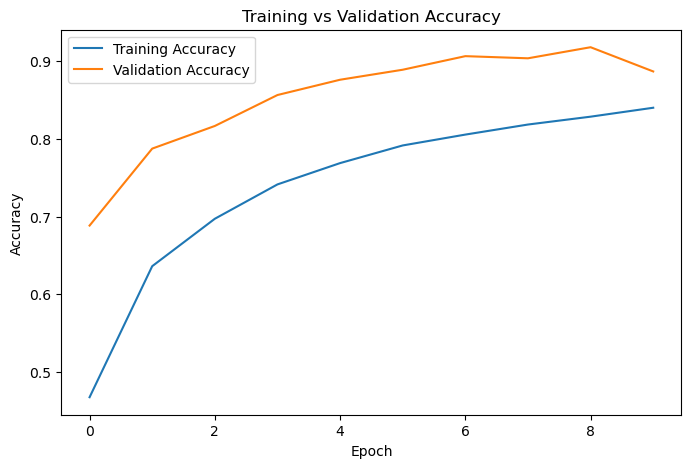

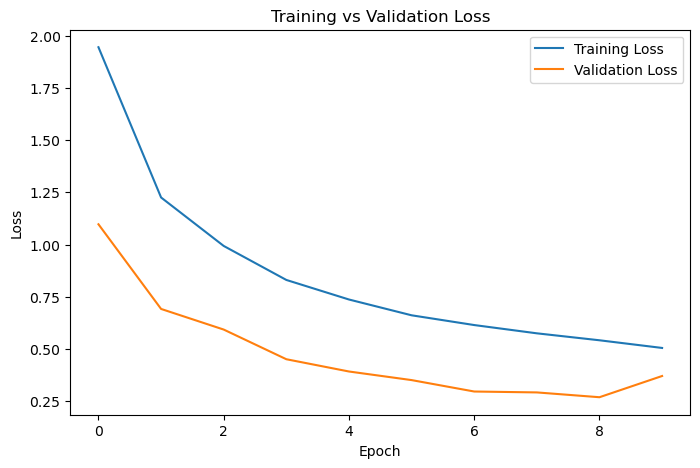

In [29]:
# Get the training history from the model.
# Keras stored loss and accuracy for both training and validation.
history_dict = history.history


# -------------------------------
# Plot 1: Training and Validation Accuracy
# -------------------------------

plt.figure(figsize=(8, 5))

# Plot training accuracy.
plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy"
)

# Plot validation accuracy.
plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy"
)

# Add title and axis labels.
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Display the legend.
plt.legend()

# Display the plot.
plt.show()


# -------------------------------
# Plot 2: Training and Validation Loss
# -------------------------------

plt.figure(figsize=(8, 5))

# Plot training loss.
plt.plot(
    history_dict["loss"],
    label="Training Loss"
)

# Plot validation loss.
plt.plot(
    history_dict["val_loss"],
    label="Validation Loss"
)

# Add title and axis labels.
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Display the legend.
plt.legend()

# Display the plot.
plt.show()

In [30]:
# Evaluate the trained CNN on the validation dataset
val_loss, val_accuracy = cnn_model.evaluate(
    normalized_val_dataset
)

# Display the results
print("Baseline CNN Validation Loss:", val_loss)
print("Baseline CNN Validation Accuracy:", val_accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 77s 225ms/step - accuracy: 0.9182 - loss: 0.2693
Baseline CNN Validation Loss: 0.2692735195159912
Baseline CNN Validation Accuracy: 0.9182395935058594


In [31]:
# Generate predictions for the validation dataset
y_true = []
y_pred = []

# Go through all validation batches
for images, labels in normalized_val_dataset:

    # Get model predictions
    predictions = cnn_model.predict(images, verbose=0)

    # Convert probability predictions into class numbers
    predicted_classes = np.argmax(predictions, axis=1)

    # Store actual and predicted labels
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

# Convert lists into NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of actual labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))

Number of actual labels: 10861
Number of predicted labels: 10861


In [32]:
from sklearn.metrics import classification_report

# Get the 38 class names from the original validation dataset
class_names = val_dataset.class_names

# Generate the classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

# Display the report
print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.70      0.78       126
                                 Apple___Black_rot       0.95      0.98      0.97       125
                          Apple___Cedar_apple_rust       0.96      0.84      0.89        55
                                   Apple___healthy       0.90      0.89      0.89       329
                               Blueberry___healthy       0.93      0.99      0.96       300
          Cherry_(including_sour)___Powdery_mildew       0.97      0.94      0.95       210
                 Cherry_(including_sour)___healthy       0.97      0.98      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.53      0.62       103
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       239
               Corn_(maize)___Northern_Leaf_Blight       0.76      0.93      0.

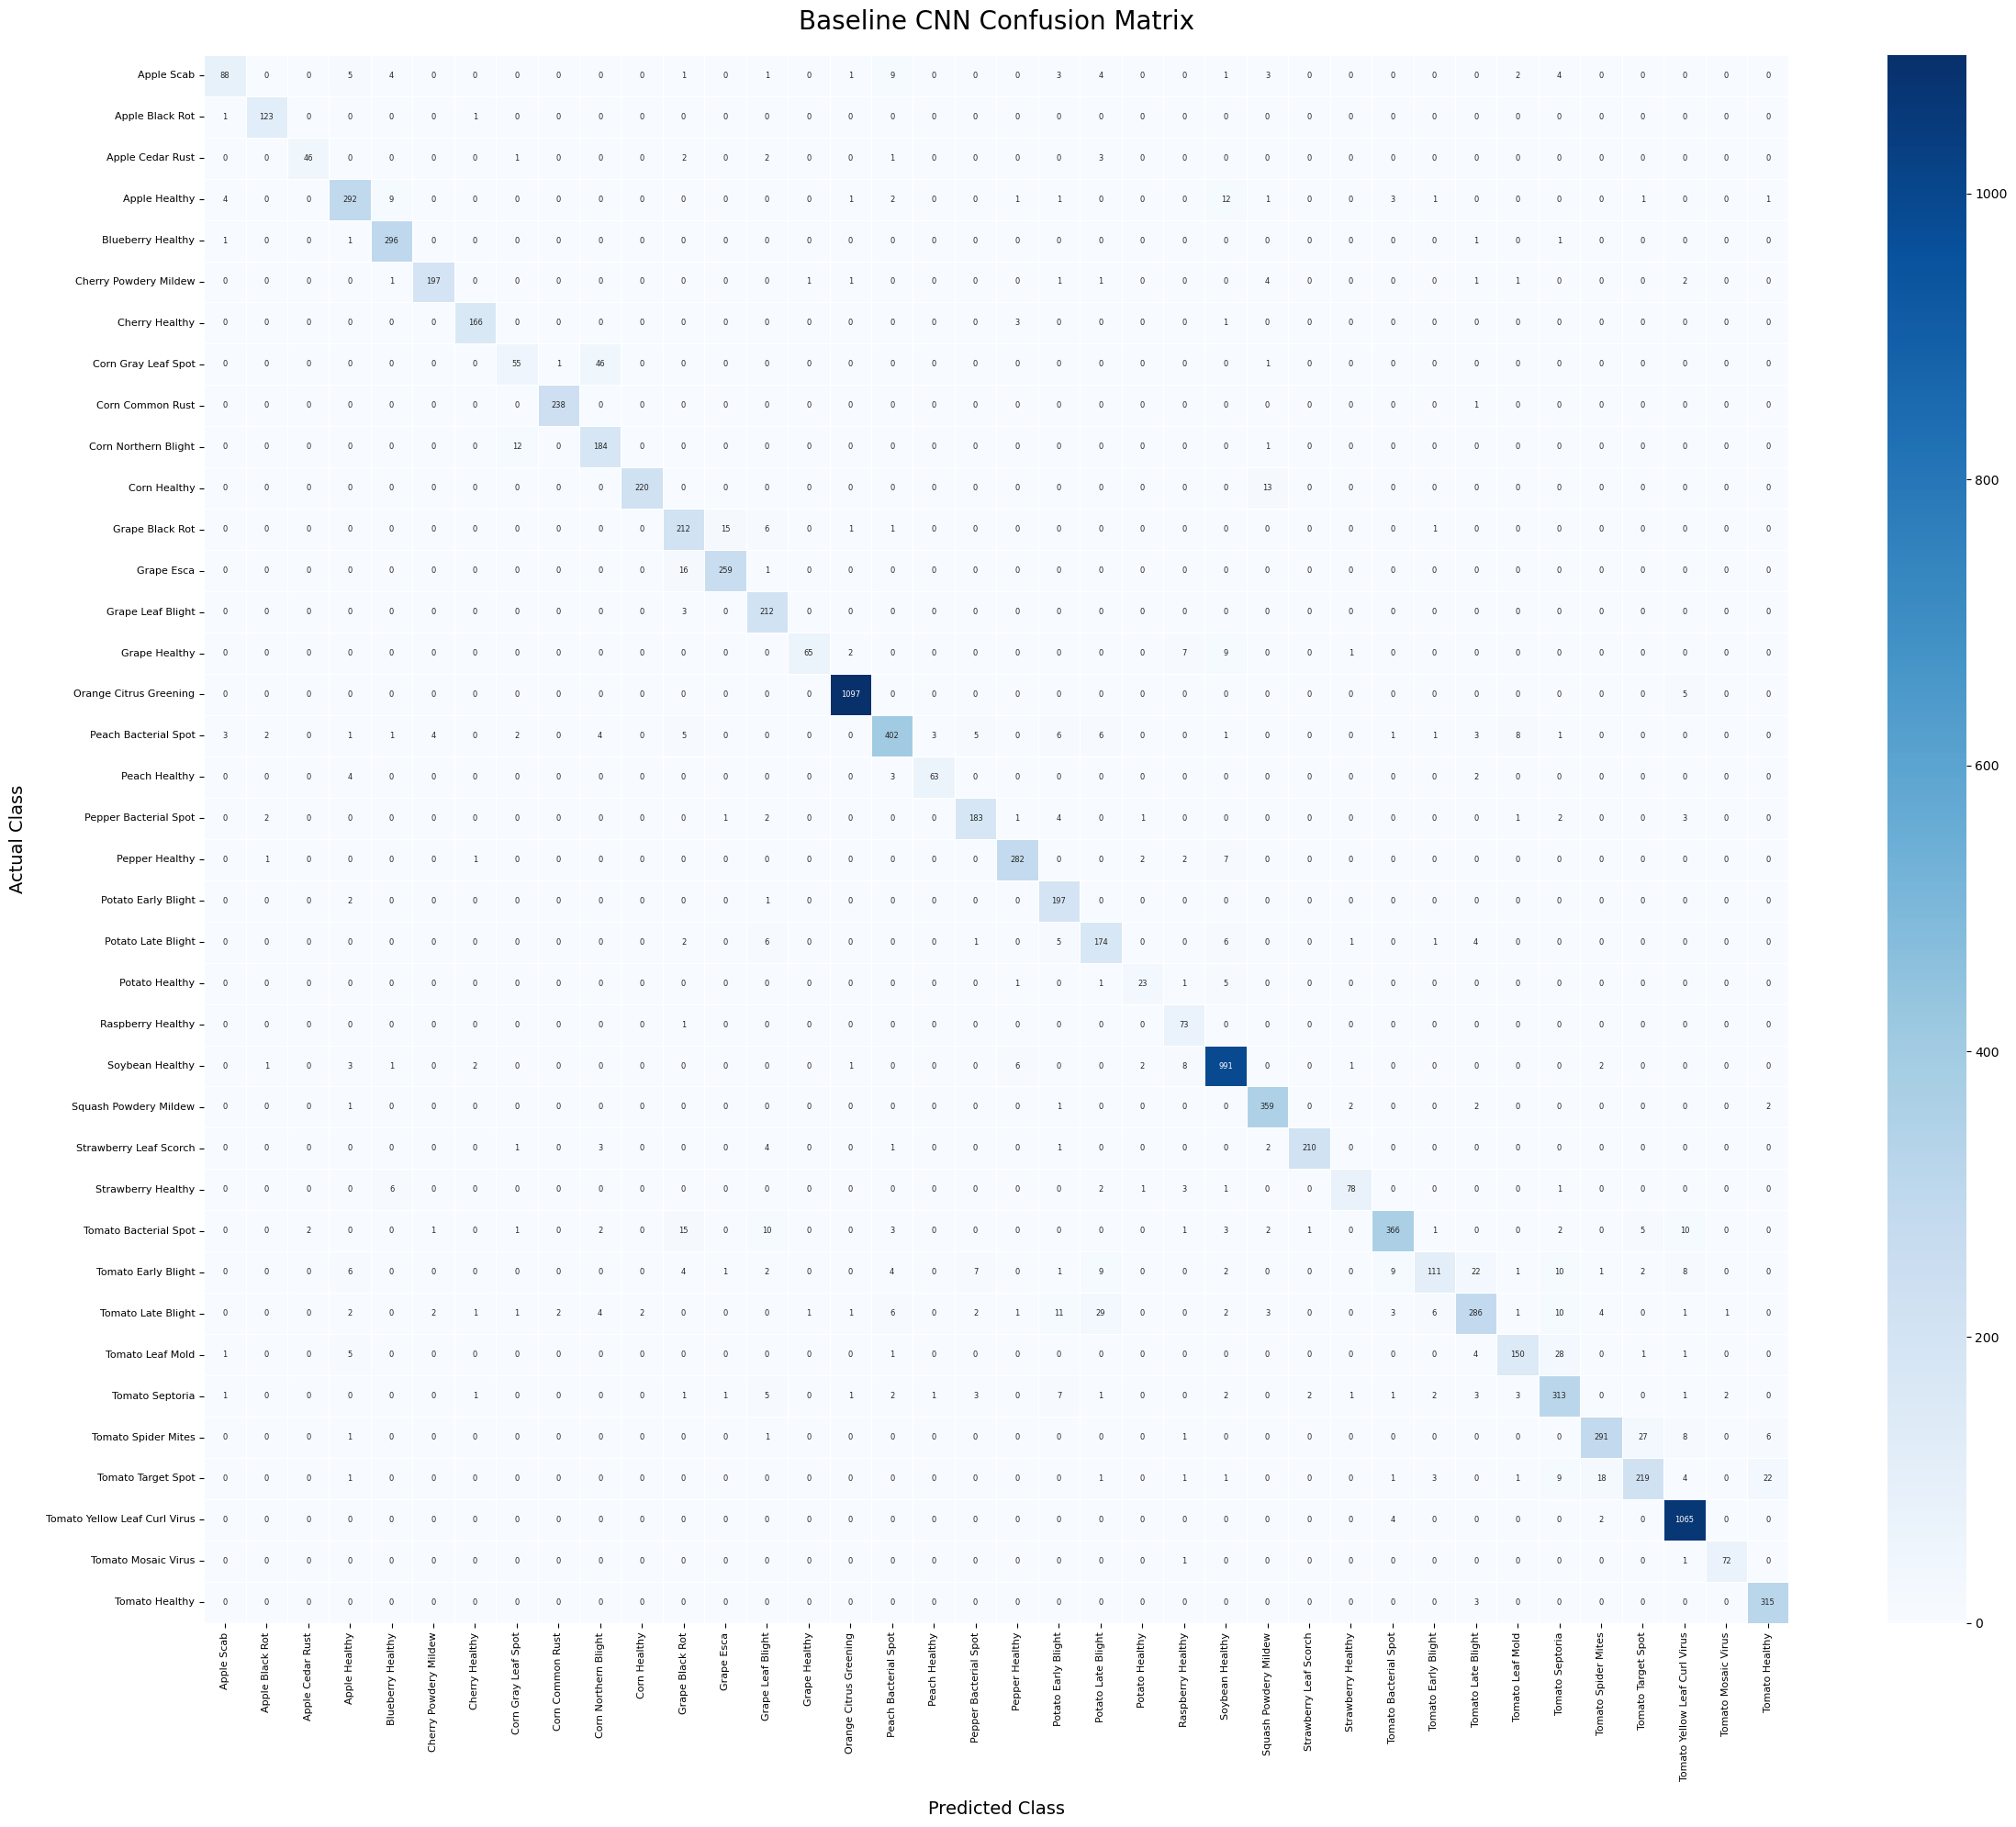

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a clean confusion matrix using the actual and predicted labels
cm = confusion_matrix(y_true, y_pred)

# Create shorter, cleaner class names for the plot
short_class_names = [
    "Apple Scab",
    "Apple Black Rot",
    "Apple Cedar Rust",
    "Apple Healthy",
    "Blueberry Healthy",
    "Cherry Powdery Mildew",
    "Cherry Healthy",
    "Corn Gray Leaf Spot",
    "Corn Common Rust",
    "Corn Northern Blight",
    "Corn Healthy",
    "Grape Black Rot",
    "Grape Esca",
    "Grape Leaf Blight",
    "Grape Healthy",
    "Orange Citrus Greening",
    "Peach Bacterial Spot",
    "Peach Healthy",
    "Pepper Bacterial Spot",
    "Pepper Healthy",
    "Potato Early Blight",
    "Potato Late Blight",
    "Potato Healthy",
    "Raspberry Healthy",
    "Soybean Healthy",
    "Squash Powdery Mildew",
    "Strawberry Leaf Scorch",
    "Strawberry Healthy",
    "Tomato Bacterial Spot",
    "Tomato Early Blight",
    "Tomato Late Blight",
    "Tomato Leaf Mold",
    "Tomato Septoria",
    "Tomato Spider Mites",
    "Tomato Target Spot",
    "Tomato Yellow Leaf Curl Virus",
    "Tomato Mosaic Virus",
    "Tomato Healthy"
]

# Create a large figure so all 38 classes can be displayed clearly
plt.figure(figsize=(24, 20))

# Plot the confusion matrix
sns.heatmap(
    cm,
    annot=True,              # Display numerical values inside cells
    fmt="d",                 # Display values as integers
    cmap="Blues",            # Blue color scheme
    xticklabels=short_class_names,
    yticklabels=short_class_names,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 6}
)

# Add title and axis labels
plt.title(
    "Baseline CNN Confusion Matrix",
    fontsize=20,
    pad=20
)

plt.xlabel(
    "Predicted Class",
    fontsize=14,
    labelpad=15
)

plt.ylabel(
    "Actual Class",
    fontsize=14,
    labelpad=15
)

# Rotate x-axis labels so they do not overlap
plt.xticks(
    rotation=90,
    fontsize=8
)

# Keep y-axis labels horizontal
plt.yticks(
    rotation=0,
    fontsize=8
)

# Adjust spacing automatically
plt.tight_layout()

# Display the confusion matrix
plt.show()

In [35]:
# Load the MobileNetV2 pretrained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,       # Remove the original ImageNet classifier
    weights="imagenet"       # Use weights learned from ImageNet
)

# Freeze the pretrained layers initially
base_model.trainable = False

# Display the MobileNetV2 architecture
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
# Build the transfer learning model
transfer_model = tf.keras.Sequential([

    # Apply the same data augmentation used in the baseline CNN
    data_augmentation,

    # Pretrained MobileNetV2 feature extractor
    base_model,

    # Convert the feature maps into a single feature vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully connected layer for learning PlantVillage-specific features
    tf.keras.layers.Dense(128, activation="relu"),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Final layer: 38 PlantVillage disease/healthy classes
    tf.keras.layers.Dense(38, activation="softmax")
])

# Compile the transfer learning model
transfer_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Display the model architecture
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (1, 7, 7, 1280)             │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (1, 1280)                   │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (1, 128)                    │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 38)                     │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
# Check whether the MobileNetV2 base model is frozen
print("MobileNetV2 trainable:", base_model.trainable)

# Count the trainable parameters
print("Trainable parameters:", transfer_model.count_params() - base_model.count_params())

MobileNetV2 trainable: False
Trainable parameters: 168870


In [38]:
# Create callbacks for the transfer learning model
transfer_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

transfer_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

# Train the transfer learning model
transfer_history = transfer_model.fit(
    normalized_train_dataset,
    epochs=5,
    validation_data=normalized_val_dataset,
    callbacks=[
        transfer_early_stopping,
        transfer_checkpoint
    ]
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2235s 2s/step - accuracy: 0.7325 - loss: 0.9216 - val_accuracy: 0.9088 - val_loss: 0.2955
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1714s 1s/step - accuracy: 0.8422 - loss: 0.4914 - val_accuracy: 0.9163 - val_loss: 0.2605
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1050s 773ms/step - accuracy: 0.8624 - loss: 0.4249 - val_accuracy: 0.9180 - val_loss: 0.2438
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1048s 771ms/step - accuracy: 0.8679 - loss: 0.4030 - val_accuracy: 0.9215 - val_loss: 0.2275
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1035s 762ms/step - accuracy: 0.8796 - loss: 0.3677 - val_accuracy: 0.9264 - val_loss: 0.2185


In [39]:
import warnings
warnings.filterwarnings('ignore')

In [40]:
import tensorflow as tf
# Load the already-trained MobileNetV2 model
transfer_model = tf.keras.models.load_model("best_mobilenetv2.keras")

print("MobileNetV2 model loaded successfully.")

MobileNetV2 model loaded successfully.


In [41]:
# Evaluate the trained MobileNetV2 transfer learning model
transfer_val_loss, transfer_val_accuracy = transfer_model.evaluate(
    normalized_val_dataset
)

print("MobileNetV2 Validation Loss:", transfer_val_loss)
print("MobileNetV2 Validation Accuracy:", transfer_val_accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 179s 521ms/step - accuracy: 0.9264 - loss: 0.2185
MobileNetV2 Validation Loss: 0.21853944659233093
MobileNetV2 Validation Accuracy: 0.9264340400695801


In [42]:
# Compare the validation performance of both models

print("Baseline CNN Validation Accuracy :", round(val_accuracy * 100, 2), "%")
print("MobileNetV2 Validation Accuracy  :", round(transfer_val_accuracy * 100, 2), "%")

improvement = (transfer_val_accuracy - val_accuracy) * 100

print("Improvement with MobileNetV2      :", round(improvement, 2), "percentage points")

Baseline CNN Validation Accuracy : 91.82 %
MobileNetV2 Validation Accuracy  : 92.64 %
Improvement with MobileNetV2      : 0.82 percentage points


In [43]:
# Generate predictions using the trained MobileNetV2 model

y_true_transfer = []
y_pred_transfer = []

for images, labels in normalized_val_dataset:
    predictions = transfer_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_transfer.extend(labels.numpy())
    y_pred_transfer.extend(predicted_classes)

y_true_transfer = np.array(y_true_transfer)
y_pred_transfer = np.array(y_pred_transfer)

# Generate the classification report
class_names = val_dataset.class_names

transfer_report = classification_report(
    y_true_transfer,
    y_pred_transfer,
    target_names=class_names
)

print(transfer_report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.79      0.88       126
                                 Apple___Black_rot       0.96      0.97      0.96       125
                          Apple___Cedar_apple_rust       0.89      0.91      0.90        55
                                   Apple___healthy       0.96      0.98      0.97       329
                               Blueberry___healthy       0.99      0.97      0.98       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       210
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.81      0.78       103
                       Corn_(maize)___Common_rust_       0.97      0.98      0.98       239
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.86      0.

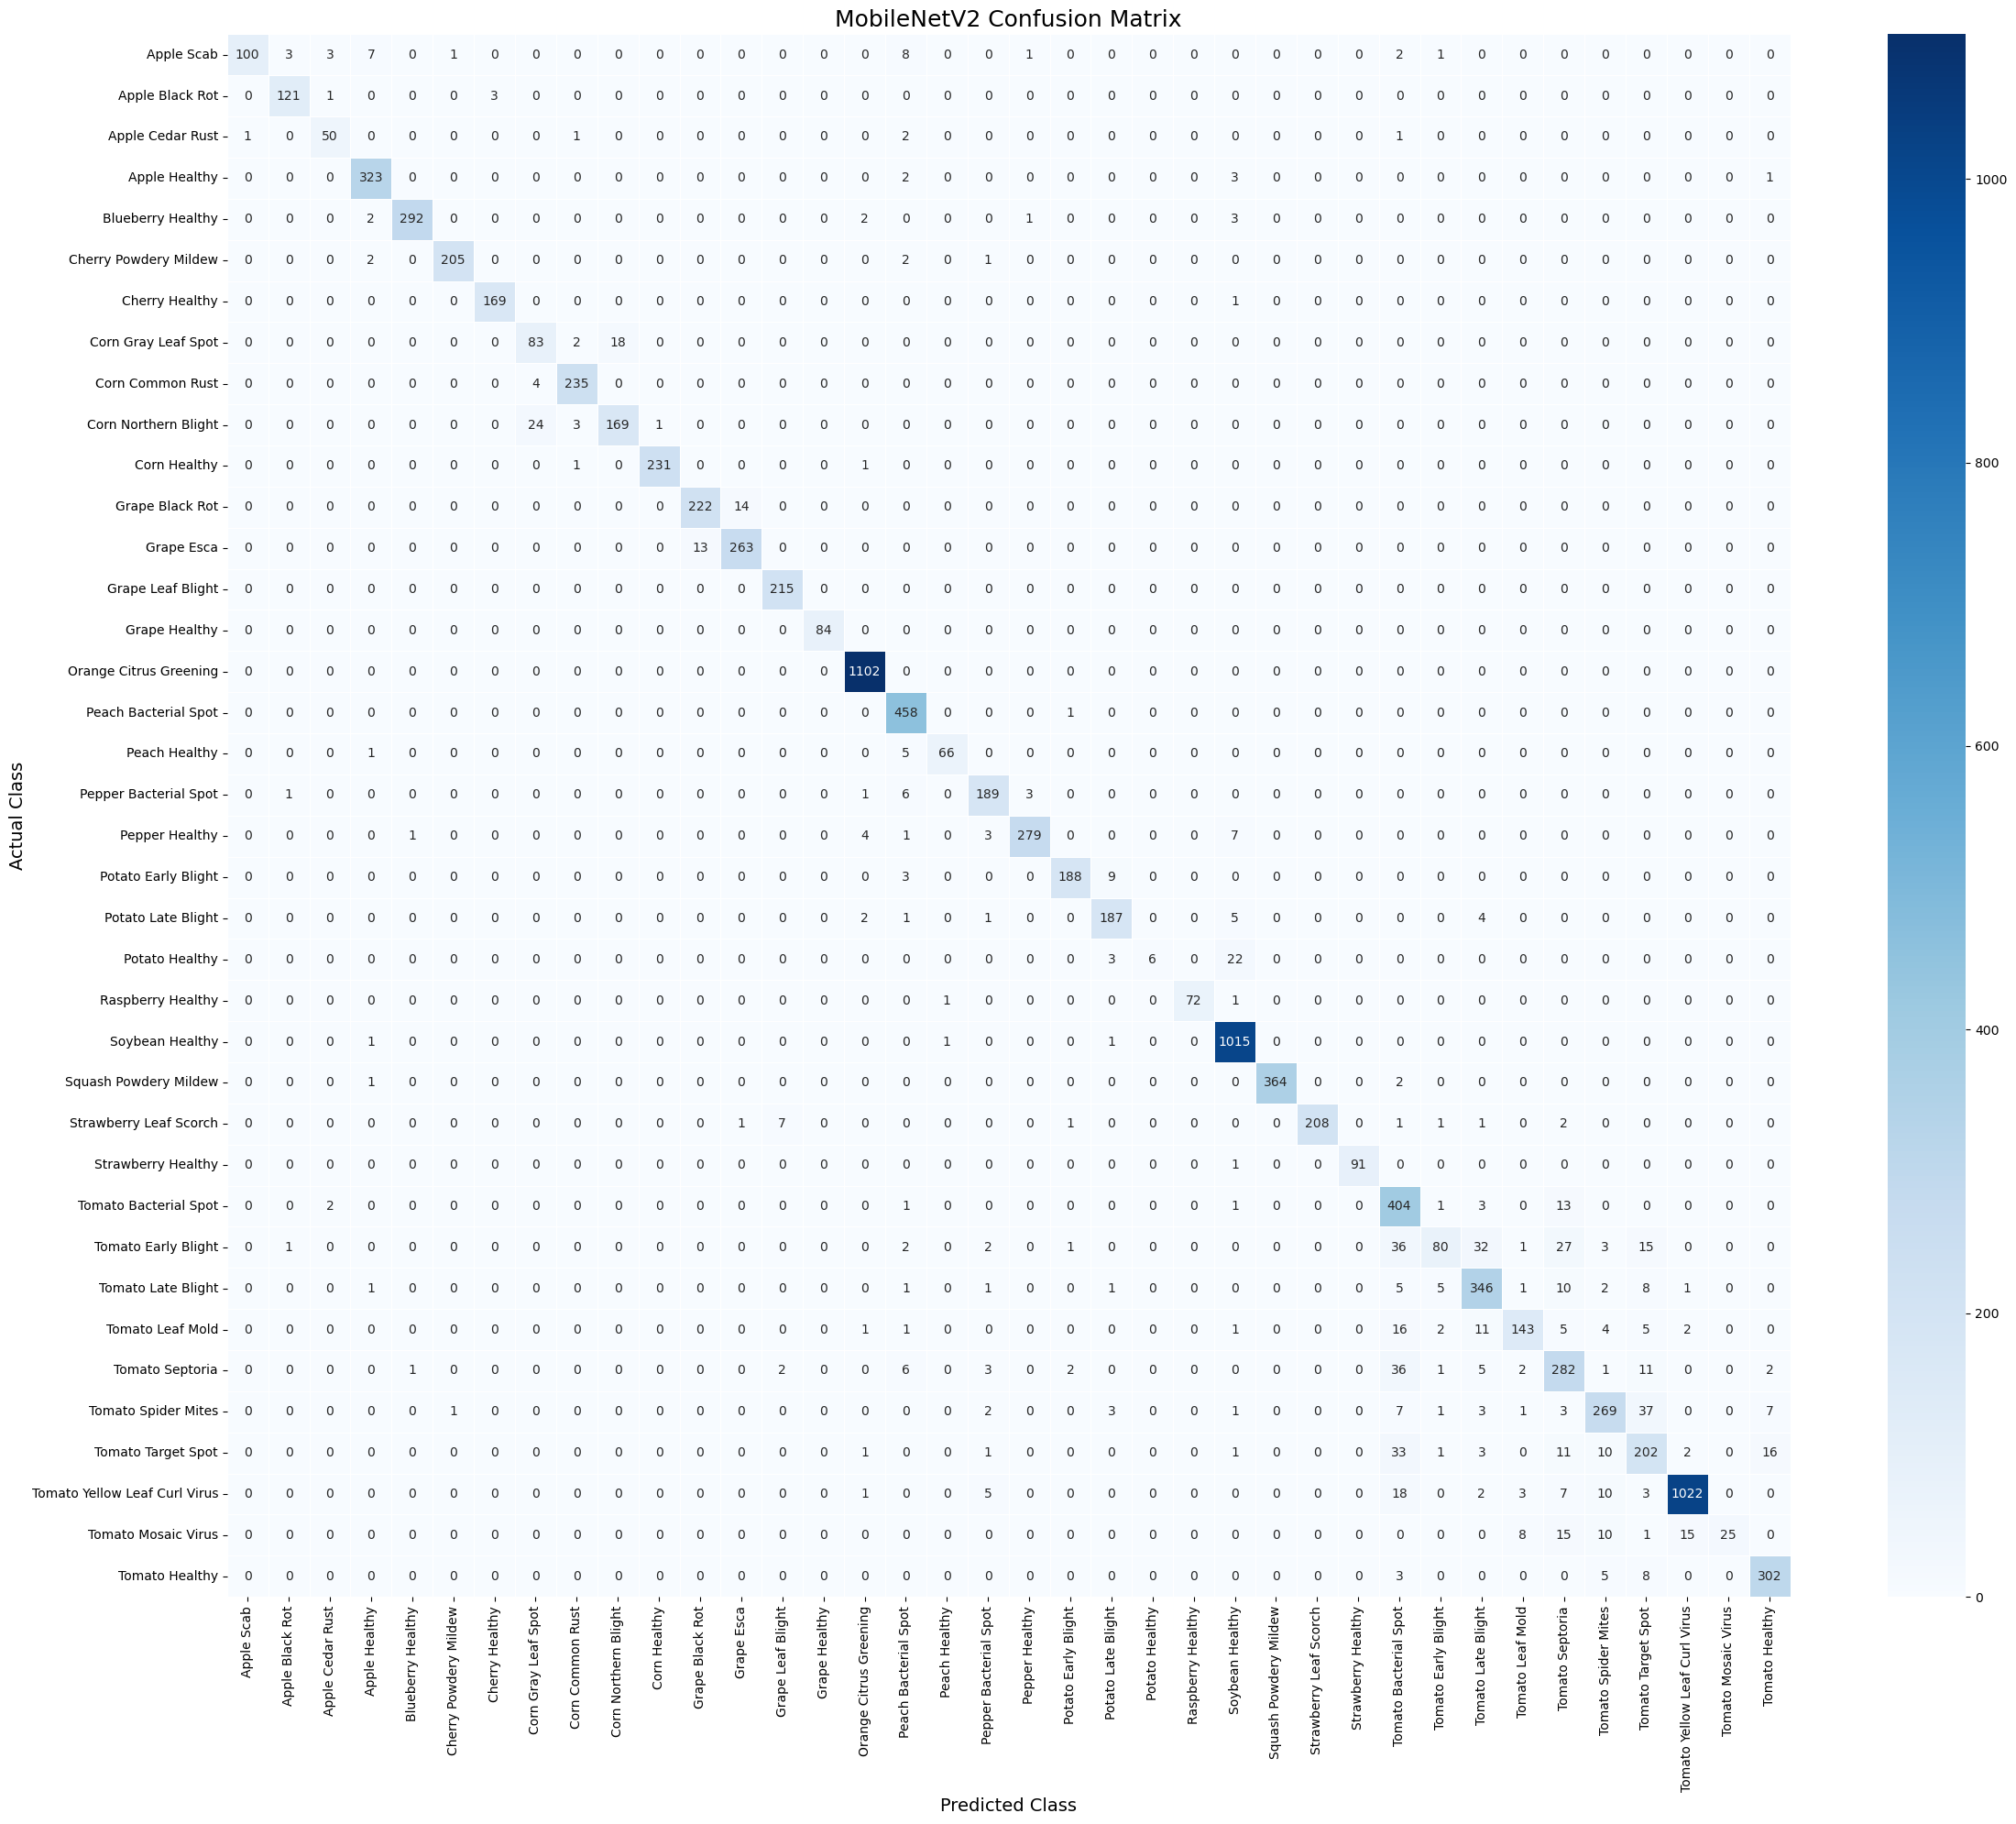

In [44]:
# Create a clean confusion matrix for the MobileNetV2 model

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_transfer = confusion_matrix(
    y_true_transfer,
    y_pred_transfer
)

plt.figure(figsize=(24, 20))

sns.heatmap(
    cm_transfer,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_class_names,
    yticklabels=short_class_names,
    linewidths=0.5
)

plt.title("MobileNetV2 Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Conclusion

This project focused on classifying plant diseases using the PlantVillage dataset containing
38 different plant disease and healthy-leaf classes.

A baseline Convolutional Neural Network (CNN) was first developed and trained for image
classification. The baseline CNN achieved a validation accuracy of 91.82%.

To improve the model, transfer learning was implemented using the pre-trained MobileNetV2
architecture with ImageNet weights. The MobileNetV2 model achieved a validation accuracy
of 92.64%, outperforming the baseline CNN by 0.82 percentage points.

The classification report showed strong performance across many plant disease classes.
However, some classes such as Potato Healthy, Tomato Early Blight, and Tomato Mosaic Virus
remained comparatively difficult to classify.

Overall, the results demonstrate that transfer learning with MobileNetV2 can provide
strong performance for multi-class plant disease classification while using substantially
fewer trainable parameters than the baseline CNN.

### Final Model

MobileNetV2 was selected as the final model because it achieved the highest validation
accuracy of 92.64%.

### Future Improvements

Future work could include fine-tuning selected MobileNetV2 layers, using a larger and more
diverse dataset, addressing difficult or underrepresented classes, and applying more
advanced image-classification architectures.